In [31]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [32]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [33]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'non_stationary_bandits', 'params.yaml')
params = load_yaml(yaml_path)


In [ ]:
TRIALS = params['TRIALS']
EPOCHS = 25 #params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR'] 
NUM_ARMS = params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']   
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

In [ ]:
env = NonStationaryEnv(
    num_arms = NUM_ARMS, 
    mean_reward = np.array([20,40,10])/SCALING_FACTOR, 
    std = np.array([2,2,2])/SCALING_FACTOR, 
    mean_rew_change = np.array([10,35,60])/SCALING_FACTOR, 
    std_change = np.array([2,2,2])/SCALING_FACTOR, 
    time_stamp_change = TIME_STAMP_CHANGE)

BEST_ARM_BEFORE = 1
BEST_ARM_AFTER = 2

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

In [36]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
LAST_BIN_PROB_MONITOR = defaultdict(dict)

In [37]:
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0] #0.01, 0.05,
VAR_ARR = [0.25,0.01, 0.04, 0.39] # Normal, PD, STD DBS, Sector DBS

In [ ]:
for var in tqdm(VAR_ARR):
    for del_lim in DEL_LIM_ARR:
        # print(f'Running for del lim = {del_lim} and var = {var}')
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      TRIALS = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = None, #'rossler',
                                                      d1_amp=1,
                                                      d2_amp=0.01,#0.3, 
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=del_lim, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = var,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
        

        ARM_MONITOR[var][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[var][del_lim] = reward_monitor
        DP_MONITOR[var][del_lim] = dp_monitor
        IP_MONITOR[var][del_lim] = ip_monitor
        ARM_TRACKER[var][del_lim] = arm_tracker_full


        OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_arm(ARM_TRACKER[var][del_lim][epoch]) for epoch in range(len(ARM_TRACKER[var][del_lim]))])
        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[var][del_lim])
        NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
        PROB = np.mean(NUMBER_OF_MATCHES,axis = 1)
        last_bin_prob = PROB[-1]


        OPTIMAL_CHOICE_MONITOR[var][del_lim] = OPTIMAL_CHOICE_ARRAY
        ACTUAL_CHOICE_MONITOR[var][del_lim] = ACTUAL_CHOICE_ARRAY
        PROB_OPTIMAL_MONITOR[var][del_lim] = PROB
        LAST_BIN_PROB_MONITOR[var][del_lim] = last_bin_prob
        print(f'del_lim = {del_lim} and var = {var}: mean prob of optimal arm = {last_bin_prob}')




  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.1 and var = 0.25: mean prob of optimal arm = 0.44666666666666666


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.2 and var = 0.25: mean prob of optimal arm = 0.4866666666666667


...

del_lim = 0.2 and var = 0.39: mean prob of optimal arm = 0.5466666666666666


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.5 and var = 0.39: mean prob of optimal arm = 0.5533333333333333


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 1.0 and var = 0.39: mean prob of optimal arm = 0.5466666666666666


In [41]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
var = {'normal': VAR_ARR[0], 'PD': VAR_ARR[1], 'std_DBS': VAR_ARR[2], 'sector_DBS': VAR_ARR[3]}
Last_bin_Probs_PD = [LAST_BIN_PROB_MONITOR[var['PD']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_std_DBS = [LAST_BIN_PROB_MONITOR[var['std_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_sector_DBS = [LAST_BIN_PROB_MONITOR[var['sector_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

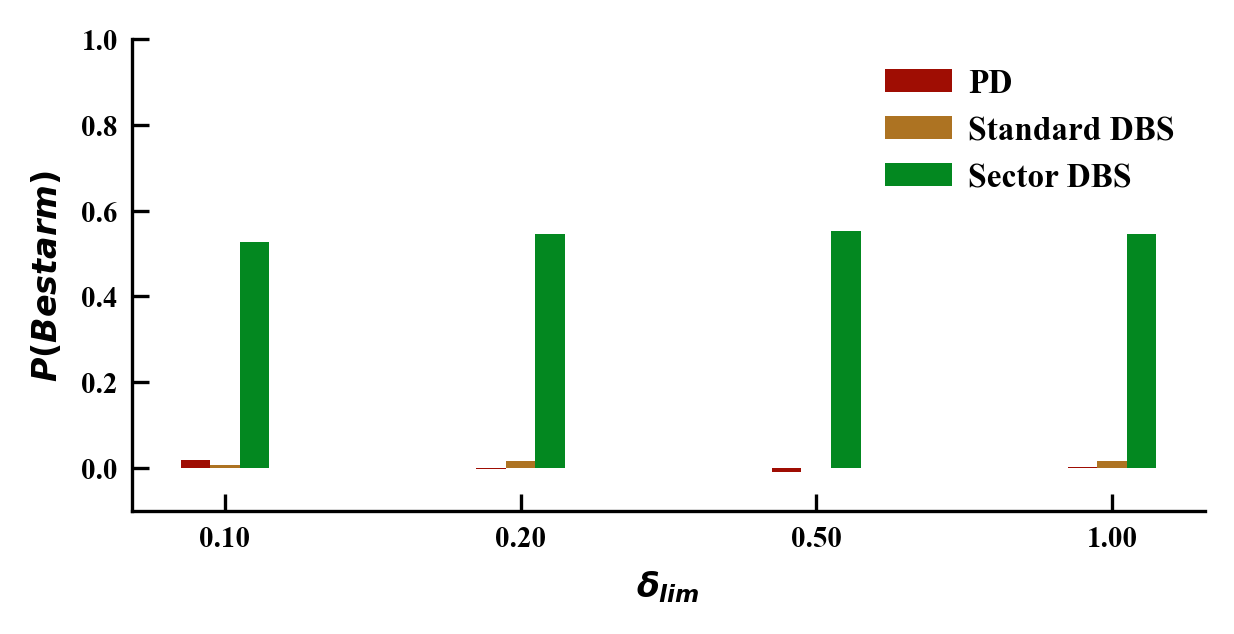

In [42]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}



plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_Probs_PD + np.random.randn(len(Last_bin_Probs_PD))*0.01, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_Probs_std_DBS+ np.random.randn(len(Last_bin_Probs_std_DBS))*0.01, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 1)
plt.show()